# Cell Line Clustering
Feasability testing suggests performing UOT on the cell line data is possible at a relatively large scale using 4 Mb at 85%. Here, we'll test this and see if it gives decent clustering.

## Imports 

In [2]:
### Enabling autoreload ##
%load_ext autoreload
%autoreload 2

In [7]:
### Directories and Files ###
root = '../../../../../'
metadata_dir = root+'Generated Data/Single-to-single/sc_uot_ramani/Metadata/maxnorm_total_mass.csv'
data_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/ramani_cool_files' # Importing was not working with relative root+'..' approach, so replace with local data
save_dir = root+'Generated Data/Single-to-single/sc_uot_ramani/Clustering'

In [9]:
### Imports ###
import sys
import os
import numpy as np
import pandas as pd
import cooler
import re
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from time import perf_counter
sys.path.append(root+'Scripts')
from hicdatautils import import_cool_dir, hic_ot_bulk_clr

In [8]:
### Pre-importing metadata ###
metadata_df = pd.read_csv(metadata_dir, index_col=0)
metadata_df

,cell_name,total_mass_1mb_87,total_mass_1mb_95,total_mass_1mb_98,total_mass_2mb_85,total_mass_4mb_85,cell_line
0,cell231_HAP1_,1941.566416,938.503117,360.011112,516.899966,120.767018,HAP1
1,cell447_HAP1_,571.521891,495.144885,289.556840,136.625814,34.354590,HAP1
2,cell470_HAP1_,586.339846,490.376493,275.947577,138.433529,45.520736,HAP1
3,cell312_HAP1_,1108.256462,741.299690,328.747511,265.206067,69.050665,HAP1
4,cell29_HAP1_,1675.821060,883.559129,355.572255,435.640040,113.949017,HAP1
...,...,...,...,...,...,...,...
615,cell63_HeLa_,1577.132727,831.020976,352.527350,403.021046,110.950627,HeLa
616,cell54_HeLa_,1417.336487,833.285618,352.084282,354.485148,86.897894,HeLa
617,cell549_K562_,1388.605358,838.461384,350.797609,338.676013,90.951444,K562
618,cell219_HeLa_,1573.195954,869.111472,362.481811,391.248261,97.703535,HeLa


## Helper Functions

### Data Handling

In [ ]:
def subset_clr_data(data_dir: str, metadata: pd.DataFrame, count: int=20, seed: int=42) -> list[cooler.Cooler]:
    '''
        Takes a directory of cooler files, selects the number of cells specified
        by count per cell line given in metadata.

        Function is specific to formatting in this notebook.

        Parameters
        ----------
        data_dir : str
            The path to the folder containing the data.
        metadata : pd.DataFrame
            Metadata dataframe providing a mapping for file to cell
            line.
        count : int
            Number of cells to import per cell line.
            Default = 20.
        seed : int
            Seed used for randomization
            Default = 42.

        Returns
        -------
        clrs_subset : list(cooler.Cooler)
            List of coolers from specified subset.
    '''
    # Selecting files
    sampled_files = (
        metadata.groupby('cell_line')
                .apply(lambda x: x.sample(
                    n=min(len(x), count),
                    replace=False,
                    random_state=seed
                ))
                .reset_index(drop=True)
    )
    samples = list(sampled_files["cell_name"])

    # Importing coolers
    clrs_subset = import_cool_dir(data_dir, include=samples)
    return clrs_subset

def long_transform(ot_data: pd.DataFrame, metadata: pd.DataFrame) -> pd.DataFrame:
    '''
        Takes a file-to-file comparisons matrix with OT results and
        transforms these results into a long format, also providing
        row and column cell lines.

        Parameters
        ----------
        ot_data : pd.DataFrame
            File-to-file format OT results.
        metadata : pd.DataFrame
            Metadata providing the cell line per file name.
        
        Returns
        -------
        ot_results_long : pd.DataFrame
            Long format dataframe additionally giving row and column
            cell lines.
    '''
    # Mapping file to type
    type_lookup = metadata.set_index("cell_name")["cell_line"]

    # Long format
    ot_results_long = ot_data.reset_index().rename(columns={"index": "row_file"})
    ot_results_long = ot_results_long.melt(id_vars="row_file",
                        var_name="col_file",
                        value_name="value")
    
    # Mapping celltypes
    ot_results_long["row_cell_line"] = ot_results_long["row_file"].map(type_lookup)
    ot_results_long["col_cell_line"] = ot_results_long["col_file"].map(type_lookup)

    # Inter and intra
    ot_results_long["relationship"] = (
        ot_results_long["row_cell_line"] == ot_results_long["col_cell_line"]
        ).map({True: "intra", False: "inter"})

    return ot_results_long

def generate_ot_data(res: int=1, thres: int=95, reg_m: float = 10, count: int=20, 
                     seed: int=42) -> tuple[pd.DataFrame, float]:
    '''
        Generates pair-wise OT comparison data for the cell line data
        using the provided arguments. Additionally, keeps track of computation
        time.

        Function is specific to this notebook.

        Parameters
        ----------
        res : int
            Resolution to bin the data to in Mb.
            Default = 1.
        thres : int
            Threshold to use for the data.
            Default = 95.
        reg_m : float
            Unbalanced parameter to use.
            Default = 10.
        cell_count : int
            The top number of cells to be used.
            Default = 20.
        seed : int
            Seed for subsetting
            Default = 42.

        Returns
        -------
        ot_results_long : pd.DataFrame
            Long format pandas dataframe with the desired results.
    '''
    # Subsetting
    clrs = subset_clr_data(data_dir, metadata_df, count, seed)
    
    # OT
        # Starting timer
    start_time = perf_counter()

        # Calculations
    ot_results = hic_ot_bulk_clr(clrs, clrs, chrom='chr1', res=res, thres=thres,
                                 thres_type='percentile', norm='max', unbalanced=reg_m)
    
        # Stopping timer
    end_time = perf_counter() - start_time

        # Saving results
    ot_results.to_csv(f'{save_dir}/CELL_LINES_unbalanced_reg_m={reg_m}_cluster_{res}mb_{thres}_{count}_seed={seed}.csv')

    # Transforming to long format
    ot_results_long = long_transform(ot_results, metadata_df)

    return ot_results_long, end_time

def load_ot_results_long(folder: str, res: int, thres: int, reg_m: float,
                         metadata: pd.DataFrame, count: int=20, seed: int=42) -> pd.DataFrame:
    '''
        Loads all csv files corresponding to OT results
        in the given folder.

        This function is very specific to this notebook.

        Parameters
        ----------
        folder : str
            Path to folder that is to be imported.
        res : int
            Resolution used for analysis.
        thres : int
            Threshold used for analysis.
        reg_m : float
            Unbalanced parameter used.
        metadata : pd.Dataframe
            Metadata providing the cell line per file name.
        count : int
            Number of cells used for analysis.
            Default = 20.
        seed : int
            Seed used to select data.
            Default = 42.
        
        Returns
        -------
        ot_df_long : pd.Dataframe
            Long form dataframe with combined data from all
            OT results.
    '''
    # File
    file = f"{save_dir}/CELL_LINES_unbalanced_reg_m={reg_m}_cluster_{res}mb_{thres}_{count}_seed={seed}.csv"

    # Importing file
    ot_df = pd.read_csv(file, index_col=0)

    # Covert to long and concatenate
    ot_df_long = long_transform(ot_df, metadata)

    # Removing duplicates
        # Sorted representation of each pair
    ot_df_long[['file_min', 'file_max']] = np.sort(ot_df_long[['row_file', 'col_file']], axis=1)

        # Drop duplicates based on the sorted pair
    ot_df_long = ot_df_long.drop_duplicates(subset=['file_min', 'file_max'])

        # Remove helper columns
    ot_df_long = ot_df_long.drop(columns=['file_min', 'file_max'])
    return ot_df_long

def add_mass_to_long_df(long_df: pd.DataFrame, metadata: pd.DataFrame, res: int, thres: int) -> pd.DataFrame:
    '''
        Adds total mass to long format dataframe.
        Assumes total_mass to be formatted as generated in this notebook.

        Parameters
        ----------
        long_df : pd.DataFrame
            Long format dataframe with OT data.
        metadata : pd.DataFrame
            Dataframe with file names and masses.
        res : int
            Used resolution. Selects mass to use.
        thres : int
            Used threshold. Selects mass to use.
        
        Returns
        -------
        long_df_mass : pd.DataFrame
            Long format dataframe with added mass metadata columns
    '''
    # Mass column name
    col = f'total_mass_{res}mb_{thres}'

    # Making mass map
    mass_map = metadata.copy()
    mass_map = mass_map.set_index('cell_name')[col]

    # Adding row and col masses
    long_df_mass = long_df.copy()
    long_df_mass['row_mass'] = long_df_mass['row_file'].map(mass_map)
    long_df_mass['col_mass'] = long_df_mass['col_file'].map(mass_map)

    # Adding additional metrics
    long_df_mass['mass_sum'] = long_df_mass["row_mass"] + long_df_mass['col_mass']
    long_df_mass['mass_diff'] = abs(long_df_mass["row_mass"] - long_df_mass['col_mass'])
    long_df_mass['log_value'] = np.log10(long_df_mass['value'])
    return long_df_mass

### Visualizing

In [41]:
def distribution_plot(data: pd.DataFrame, ax, seed: int, reg_m: float):
    '''
        Plots the distribution of the provided dataframe to
        the provided Axes object.

        Function is very specific to this notebook.

        Parameters
        ----------
        data : pd.DataFrame
            Data to be plotted.
        ax
            Axes object to plot to.
        seed : int
            Used seed.
        reg_m : float
            Used value for reg_m.
    '''
    # Setting order
    order = ["inter", "intra"]

    # Stripplot
    sns.stripplot(
    data=data,
    x="relationship",
    y="value",
    order=order,
    hue="relationship",
    dodge=False,
    jitter=True,
    alpha=0.05,
    palette={
        "inter": "#1f77b4",
        "intra": "#ff7f0e"
    },
    ax=ax
    )

    # Violin plot
    sns.violinplot(
        data=data,
        x="relationship",
        y="value",
        order=order,
        inner=None,
        color="lightgray",
        cut=0,
        ax=ax
    )

    ax.set_ylim(bottom=0)
    ax.set_ylabel("OT Loss")
    ax.set_title(f"UOT for seed={seed}, reg_m={reg_m}")
    return

def generate_clustermap(data: pd.DataFrame, reg_m: float, seed: int):
    '''
        Generates a clustermap between cell types for the data generated
        in this notebook.

        Function is specific to this notebook.

        Parameters
        ----------
        data : pd.DataFrame
            Long format dataframe with cell-to-cell comparisons.
        reg_m : float
            Used reg_m value.
        seed : int
            Used seed for data selection.
    '''
    # Calculating means per cell type
    mean_matrix = data.groupby(
        ['row_cell_line', 'col_cell_line']
    )["value"].mean()

    # Prepping for generating heatmap
    heatmap_data = mean_matrix.unstack()

    # Clustermap
    sns.clustermap(heatmap_data, annot=True, fmt='.1f', cmap='viridis')
    plt.suptitle(f"Cell Lines Unbalanced (reg_m={reg_m}, seed={seed})", fontweight='bold')
    plt.tight_layout()

    return

def generate_marginal_plot(long_df: pd.DataFrame, mass_df: pd.DataFrame, reg_m: float, 
                           seed: int, res: int, thres: int, kind: str = 'diff'):
    '''
        Generates marginal plots for metadata in long_df_mass.

        Parameters
        ----------
        long_df : pd.DataFrame
            Long format dataframe with OT results.
        mass_df : pd.DataFrame
            Dataframe with file to mass mappings.
        reg_m : float
            reg_m value used for UOT.
        seed : int
            Seed used for data selection.
        res : int
            Used resolution. Selects mass to use.
        thres : int
            Used threshold. Selects mass to use.
        kind : str
            Kind of comparison to plot.
            'sum' = mass sum to OT loss.
            'diff' = mass difference to OT loss.
            Default = 'diff'
    '''
    sns.set_theme(style="white")

    # Adding mass data
    long_df_mass = add_mass_to_long_df(long_df, mass_df, 4, 85)

    # Setting comparison
    if kind == 'sum':
        compare = 'mass_sum'
        axis_title = 'Mass Sum'
    elif kind == 'diff':
        compare = 'mass_diff'
        axis_title = 'Mass Difference'
    else:
        raise ValueError(f"Invalid kind: {kind}")

    # Initialize grid
    g = sns.JointGrid(
        data=long_df_mass,
        x=compare,
        y='log_value',
        height=6
    )

    # Joint: light scatter + contour KDE
    g.ax_joint.scatter(
        long_df_mass[compare],
        long_df_mass['log_value'],
        s=8,
        alpha=0.25
    )

    sns.kdeplot(
        data=long_df_mass,
        x=compare,
        y='log_value',
        ax=g.ax_joint,
        levels=10,
        bw_adjust=0.8,
        color='black'
    )

    # Marginals
    sns.kdeplot(
        data=long_df_mass,
        x=compare,
        ax=g.ax_marg_x,
        fill=True,
        bw_adjust=0.8
    )

    sns.kdeplot(
        data=long_df_mass,
        y='log_value',
        ax=g.ax_marg_y,
        fill=True,
        bw_adjust=0.8
    )

    # Axis labels
    g.set_axis_labels(axis_title, 'log(OT Loss)')

    # Title
    g.figure.suptitle(f'Marginal Plot OT Loss and {axis_title}, Cell lines UOT (reg_m={reg_m}, seed={seed})', fontweight='bold')
    g.figure.tight_layout(rect=[0, 0, 1, 0.98])
    return

## Generating Data

In [ ]:
### Generating data for 4 Mb, 85%, reg_m = 10 ###
generate_ot_data(4, 85, 10, 38, 42)

/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_30741/2830185994.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


(               row_file       col_file       value row_cell_line  \
 0         cell547_K562_  cell547_K562_    0.000000          K562   
 1         cell434_HeLa_  cell547_K562_  172.161143          HeLa   
 2      cell583_GM12878_  cell547_K562_  274.635407       GM12878   
 3           cell7_HeLa_  cell547_K562_  182.062486          HeLa   
 4          cell35_HAP1_  cell547_K562_  145.867018          HAP1   
 ...                 ...            ...         ...           ...   
 21604     cell537_K562_  cell381_HAP1_  271.141568          K562   
 21605     cell500_K562_  cell381_HAP1_  299.593785          K562   
 21606     cell284_HeLa_  cell381_HAP1_  306.659340          HeLa   
 21607     cell112_HeLa_  cell381_HAP1_  267.789024          HeLa   
 21608     cell381_HAP1_  cell381_HAP1_    0.000000          HAP1   
 
       col_cell_line relationship  
 0              K562        intra  
 1              K562        inter  
 2              K562        inter  
 3              K562      

Results are not very encouraging (see visualizing). Thus, we'd like to repeat this data but for a higher value of reg_m.

In [37]:
### Generating data for 4 Mb, 85%, reg_m = 50 ###
generate_ot_data(4, 85, 50, 38, 42)

/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_30741/198089905.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


(               row_file       col_file       value row_cell_line  \
 0         cell547_K562_  cell547_K562_    0.000000          K562   
 1         cell434_HeLa_  cell547_K562_  423.325390          HeLa   
 2      cell583_GM12878_  cell547_K562_  875.296056       GM12878   
 3           cell7_HeLa_  cell547_K562_  447.527064          HeLa   
 4          cell35_HAP1_  cell547_K562_  279.598419          HAP1   
 ...                 ...            ...         ...           ...   
 21604     cell537_K562_  cell381_HAP1_  761.564371          K562   
 21605     cell500_K562_  cell381_HAP1_  864.411110          K562   
 21606     cell284_HeLa_  cell381_HAP1_  963.592103          HeLa   
 21607     cell112_HeLa_  cell381_HAP1_  638.065306          HeLa   
 21608     cell381_HAP1_  cell381_HAP1_    0.000000          HAP1   
 
       col_cell_line relationship  
 0              K562        intra  
 1              K562        inter  
 2              K562        inter  
 3              K562      

In [38]:
### Generating data for 4 Mb, 85%, reg_m = 1 ###
generate_ot_data(4, 85, 1, 38, 42)

/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_30741/198089905.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


(               row_file       col_file      value row_cell_line col_cell_line  \
 0         cell547_K562_  cell547_K562_   0.000000          K562          K562   
 1         cell434_HeLa_  cell547_K562_  42.323848          HeLa          K562   
 2      cell583_GM12878_  cell547_K562_  50.251965       GM12878          K562   
 3           cell7_HeLa_  cell547_K562_  46.047964          HeLa          K562   
 4          cell35_HAP1_  cell547_K562_  38.551184          HAP1          K562   
 ...                 ...            ...        ...           ...           ...   
 21604     cell537_K562_  cell381_HAP1_  50.621378          K562          HAP1   
 21605     cell500_K562_  cell381_HAP1_  58.375735          K562          HAP1   
 21606     cell284_HeLa_  cell381_HAP1_  57.239741          HeLa          HAP1   
 21607     cell112_HeLa_  cell381_HAP1_  55.194668          HeLa          HAP1   
 21608     cell381_HAP1_  cell381_HAP1_   0.000000          HAP1          HAP1   
 
       relatio

## Loading Data

In [43]:
### Loading data for all reg_m values ###
reg_m_list = [1, 10, 50]
data_list = []

for reg_m in reg_m_list:
    data_list.append(load_ot_results_long(save_dir, 4, 85, reg_m, metadata_df, 38, 42))

## Visualizing Data

### Distribution Plot

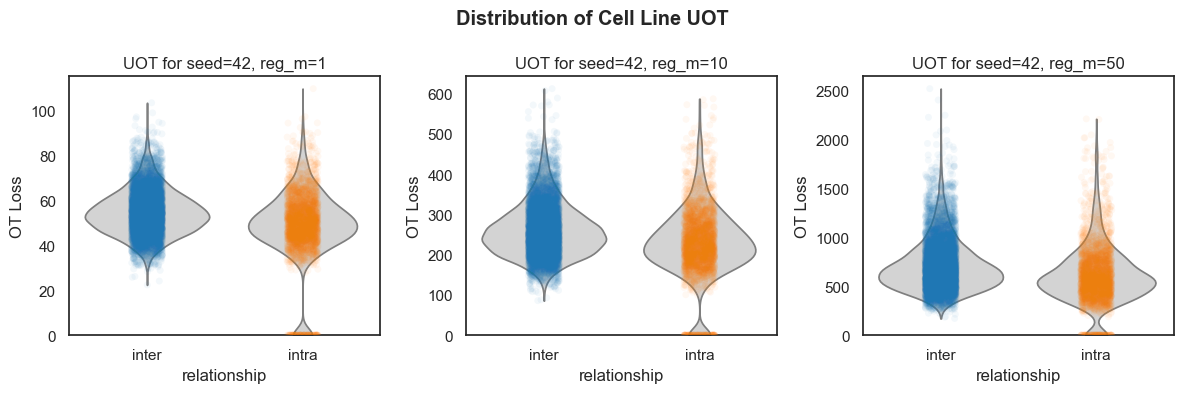

In [48]:
### Distribution Plot ###
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
axes = ax.flatten()

for data, reg_m, axis in zip(data_list, reg_m_list, axes):
    distribution_plot(data, axis, 42, reg_m)

plt.suptitle("Distribution of Cell Line UOT", fontweight='bold')
plt.tight_layout()

Distributions look relatvely similar

### Clustermap

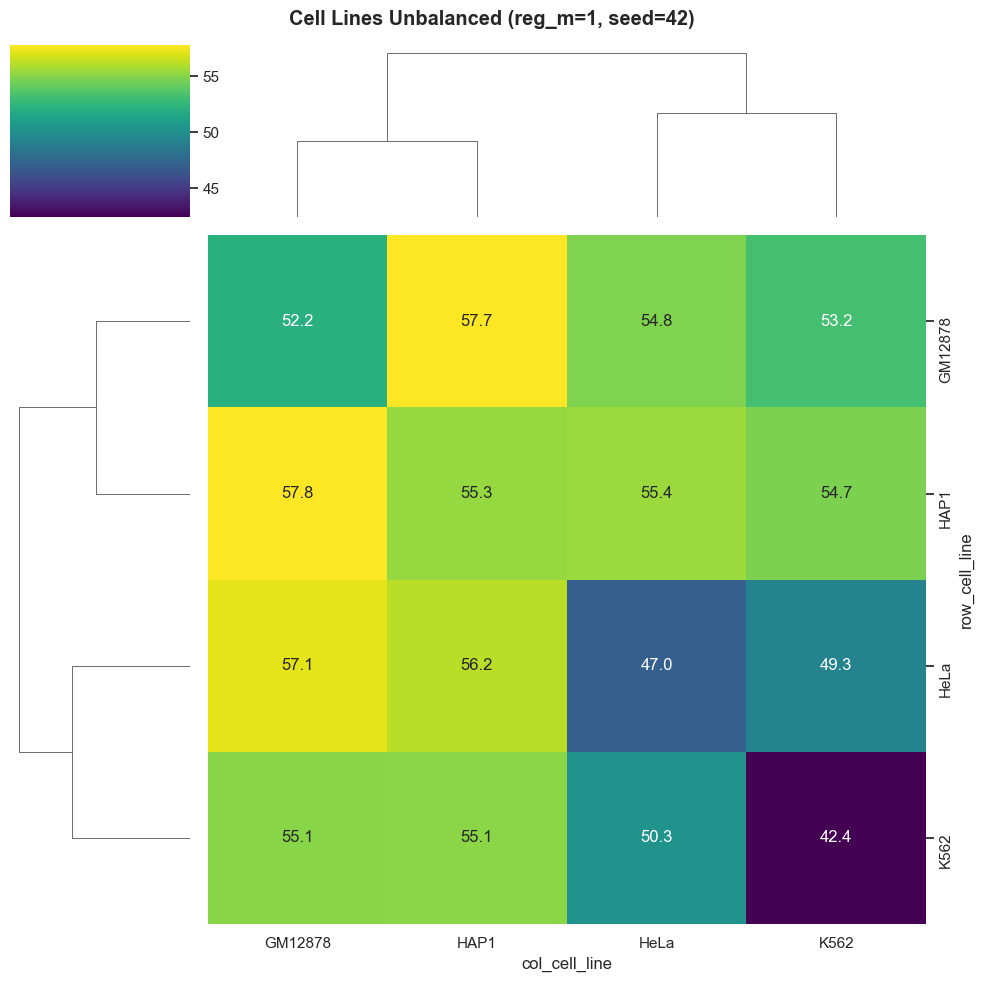

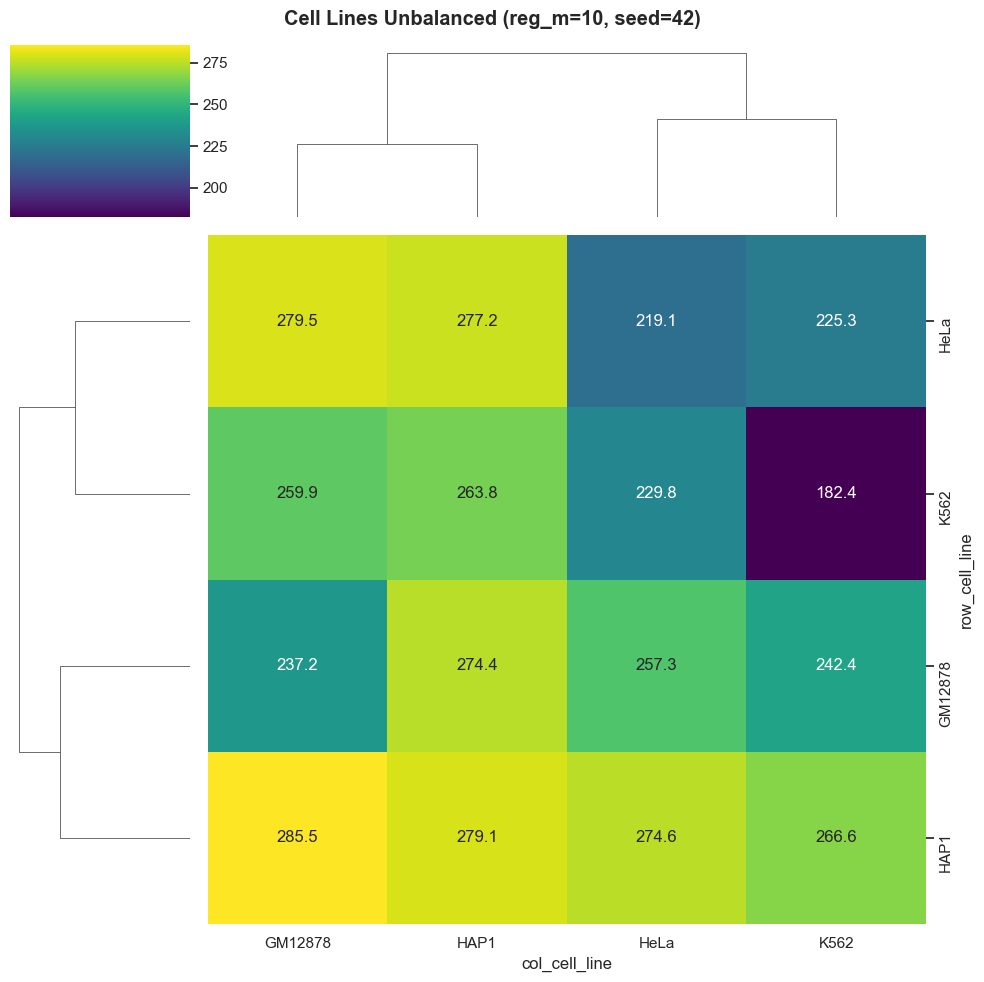

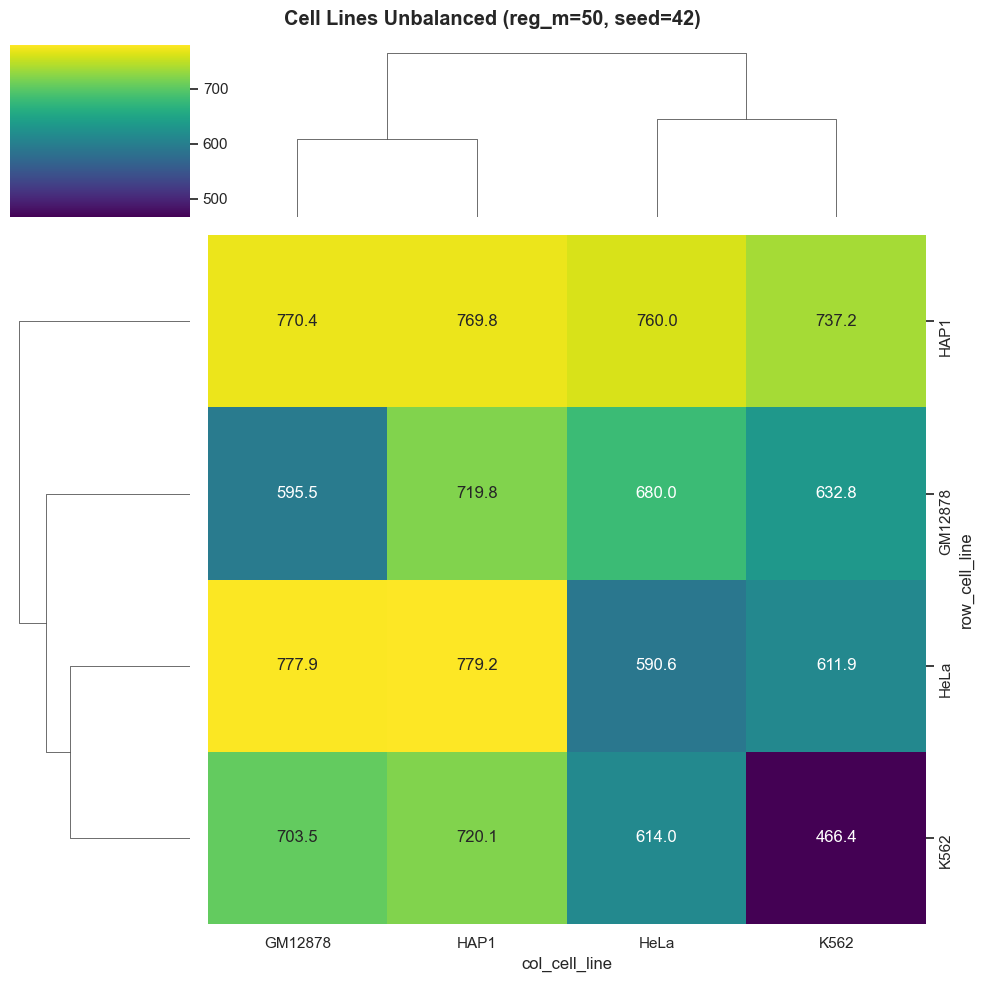

In [46]:
### Clustermap ###
for data, reg_m in zip(data_list, reg_m_list):
    generate_clustermap(data, reg_m, 42)

The main takeaway is that the results are the opposite of what UMAP data suggests (see notes previous discussion). GM12878 and HAP1 actually see the highest OT cost between each other, whereas you'd expect the lowest cost looking at the UMAP data. Furthermore, K526 and HeLa show a relatively low OT cost, when you'd expect them to have the highest OT cost.
Could be due to total mass being higher than the previous dataset (for this resolution and threshold by a factor 5), so a higher value for reg_m may be warranted. 

### Marginal Plot

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


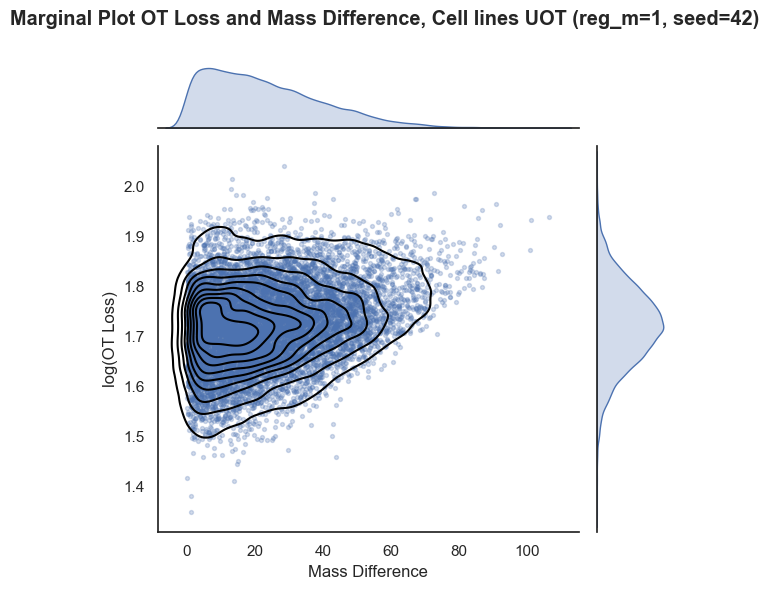

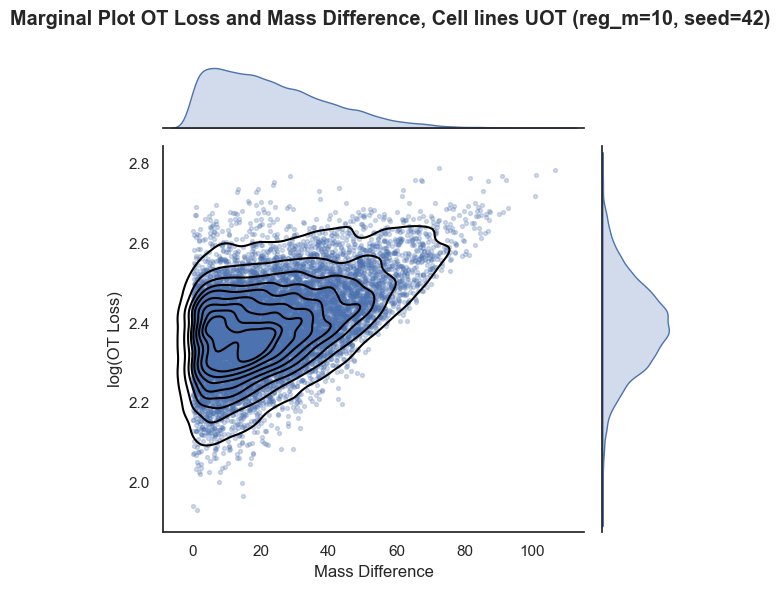

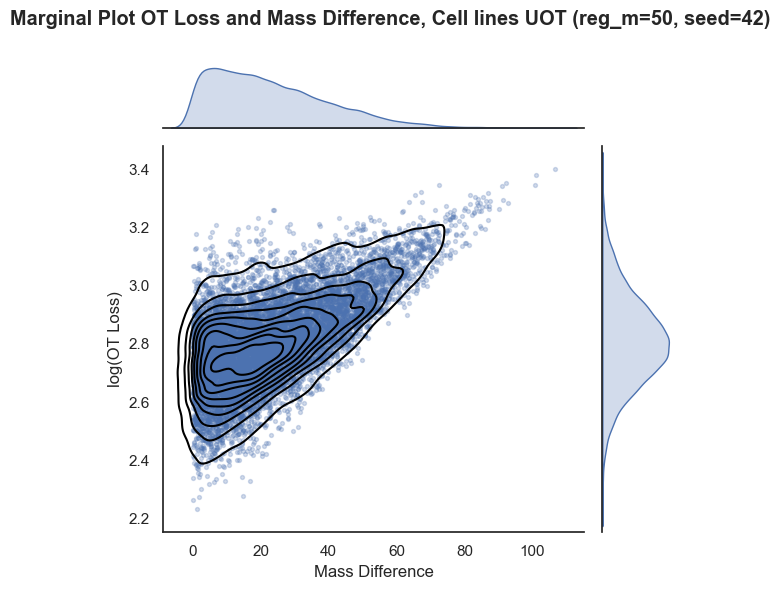

In [47]:
for data, reg_m in zip(data_list, reg_m_list):
    generate_marginal_plot(data, metadata_df, reg_m, 42, 4, 85)